In [12]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from collections import defaultdict

# Initialize tokenizer (run once)
try:
    tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-8B")
except:
    print("Install transformers: pip install transformers")

def load_data(file_path):
    """Load prediction file"""
    with open(file_path, 'r') as f:
        return json.load(f)

def get_token_count(text):
    """Count tokens in text"""
    return len(tokenizer.encode(text))

def group_by_length(data, num_bins=10, method='equal_width'):
    """Group data by document length using different binning methods"""
    # Get token counts
    token_counts = [get_token_count(item['input']) for item in data]
    
    if method == 'equal_width':
        # Original method: equal-width bins
        min_tokens, max_tokens = min(token_counts), max(token_counts)
        bin_width = (max_tokens - min_tokens) / num_bins
        
        groups = defaultdict(list)
        for item, count in zip(data, token_counts):
            bin_idx = min(int((count - min_tokens) / bin_width), num_bins - 1)
            start = int(min_tokens + bin_idx * bin_width)
            end = int(min_tokens + (bin_idx + 1) * bin_width) if bin_idx < num_bins - 1 else max_tokens
            group_key = f"{start}-{end}"
            groups[group_key].append(item)
    
    elif method == 'quantile':
        # New method: quantile-based bins (equal frequency)
        import numpy as np
        
        # Create quantile boundaries
        quantiles = np.linspace(0, 100, num_bins + 1)
        boundaries = [np.percentile(token_counts, q) for q in quantiles]
        boundaries = [int(b) for b in boundaries]
        
        groups = defaultdict(list)
        for item, count in zip(data, token_counts):
            # Find which quantile bin this belongs to
            for i in range(len(boundaries) - 1):
                if boundaries[i] <= count <= boundaries[i + 1]:
                    group_key = f"{boundaries[i]}-{boundaries[i + 1]}"
                    groups[group_key].append(item)
                    break
    
    return groups

def compute_averages(groups, metric):
    """Compute average metric for each group"""
    results = {}
    for group, items in groups.items():
        values = [item[metric] for item in items if metric in item and item[metric] is not None]
        if values:
            results[group] = {
                'avg': round(sum(values) / len(values), 4),
                'count': len(values)
            }
    return results

def sort_groups(df):
    """Sort DataFrame by numerical start of group range"""
    df['start_token'] = df['group'].str.split('-').str[0].astype(int)
    df = df.sort_values('start_token').drop('start_token', axis=1).reset_index(drop=True)
    return df

def analyze_metric(file_path, metric, num_bins=10, method='quantile', plot=True):
    """Main analysis function"""
    # Load and process data
    data = load_data(file_path)
    groups = group_by_length(data, num_bins, method)
    results = compute_averages(groups, metric)
    
    # Create DataFrame
    df = pd.DataFrame([
        {'group': k, 'average': v['avg'], 'count': v['count']} 
        for k, v in results.items()
    ])
    df = sort_groups(df)  # Sort by token count
    
    # Plot if requested
    if plot:
        plt.figure(figsize=(10, 6))
        bars = plt.bar(range(len(df)), df['average'], color='steelblue', alpha=0.7)
        plt.xlabel('Document Length Groups')
        plt.ylabel(f'Average {metric}')
        method_name = 'Equal Frequency' if method == 'quantile' else 'Equal Width'
        plt.title(f'{metric} by Document Length ({num_bins} bins, {method_name})')
        plt.xticks(range(len(df)), df['group'], rotation=45)
        
        # Add count labels
        for bar, count in zip(bars, df['count']):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'n={count}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
    
    return df

def compare_metrics(file_path, metrics, num_bins=10, method='quantile'):
    """Compare multiple metrics"""
    data = load_data(file_path)
    groups = group_by_length(data, num_bins, method)
    
    fig, axes = plt.subplots(1, len(metrics), figsize=(5*len(metrics), 4))
    if len(metrics) == 1:
        axes = [axes]
    
    for i, metric in enumerate(metrics):
        results = compute_averages(groups, metric)
        df = pd.DataFrame([
            {'group': k, 'average': v['avg']} 
            for k, v in results.items()
        ])
        df = sort_groups(df)  # Sort by token count
        
        axes[i].bar(range(len(df)), df['average'], alpha=0.7)
        axes[i].set_title(metric)
        axes[i].set_xticks(range(len(df)))
        axes[i].set_xticklabels(df['group'], rotation=45)
    
    plt.tight_layout()
    plt.show()

def plot_grouped_comparison(df1, df2, metric_name, label1="File 1", label2="File 2"):
    """Plot grouped bar chart comparing results from two DataFrames"""
    # Sort both DataFrames properly
    df1 = sort_groups(df1.copy())
    df2 = sort_groups(df2.copy())
    
    # Merge dataframes on group
    merged = pd.merge(df1[['group', 'average']], df2[['group', 'average']], 
                     on='group', suffixes=('_1', '_2'), how='outer').fillna(0)
    merged = sort_groups(merged)  # Sort merged result
    
    # Set up the plot
    x = range(len(merged))
    width = 0.35
    
    plt.figure(figsize=(12, 6))
    
    # Create grouped bars
    plt.bar([i - width/2 for i in x], merged['average_1'], width, 
            label=label1, alpha=0.8, color='steelblue')
    plt.bar([i + width/2 for i in x], merged['average_2'], width, 
            label=label2, alpha=0.8, color='orange')
    
    # Customize plot
    plt.xlabel('Document Length Groups')
    plt.ylabel(f'Average {metric_name}')
    plt.title(f'Comparison of {metric_name} by Document Length')
    plt.xticks(x, merged['group'], rotation=45)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

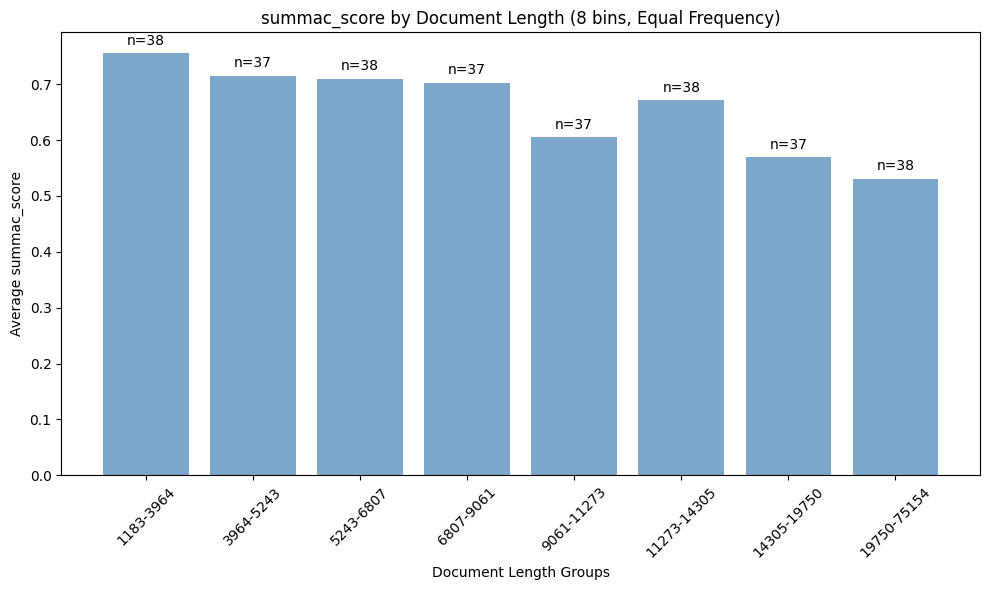

In [ ]:
data_path = "/mnt/ceph_rbd/project/context-faithful-llm/evaluate/logs/qwen3-8b_gov_report_validation_300_attr-sent30_base+impt/metrics_per_sample.json"
df2 = analyze_metric(data_path, 'summac_score', num_bins=8, method='quantile')

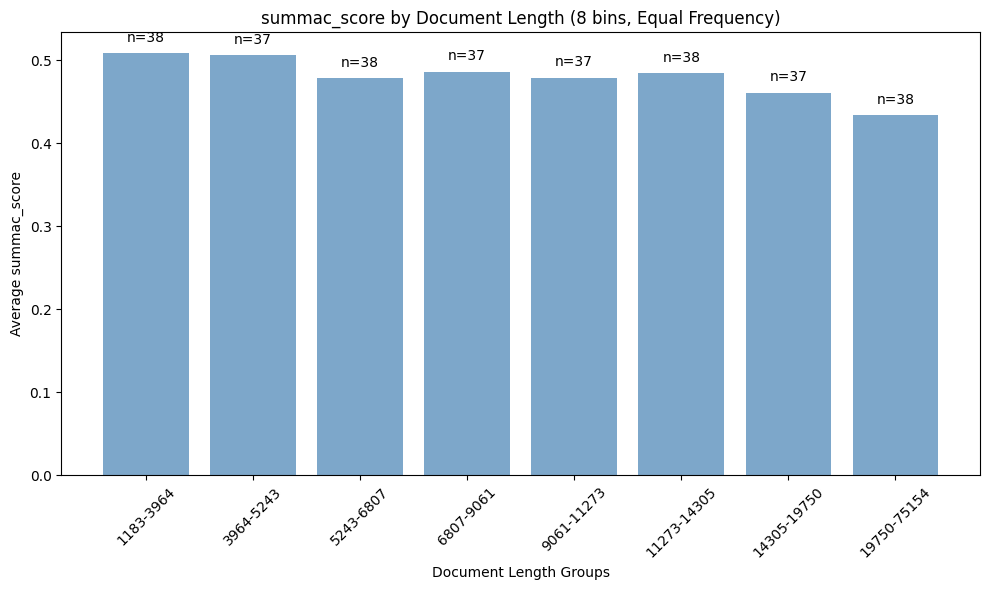

In [ ]:
data_path = "/mnt/ceph_rbd/project/context-faithful-llm/evaluate/logs/qwen3-8b_gov_report_validation_300_base/metrics_per_sample.json"
df1 = analyze_metric(data_path, 'summac_score', num_bins=8, method='quantile')

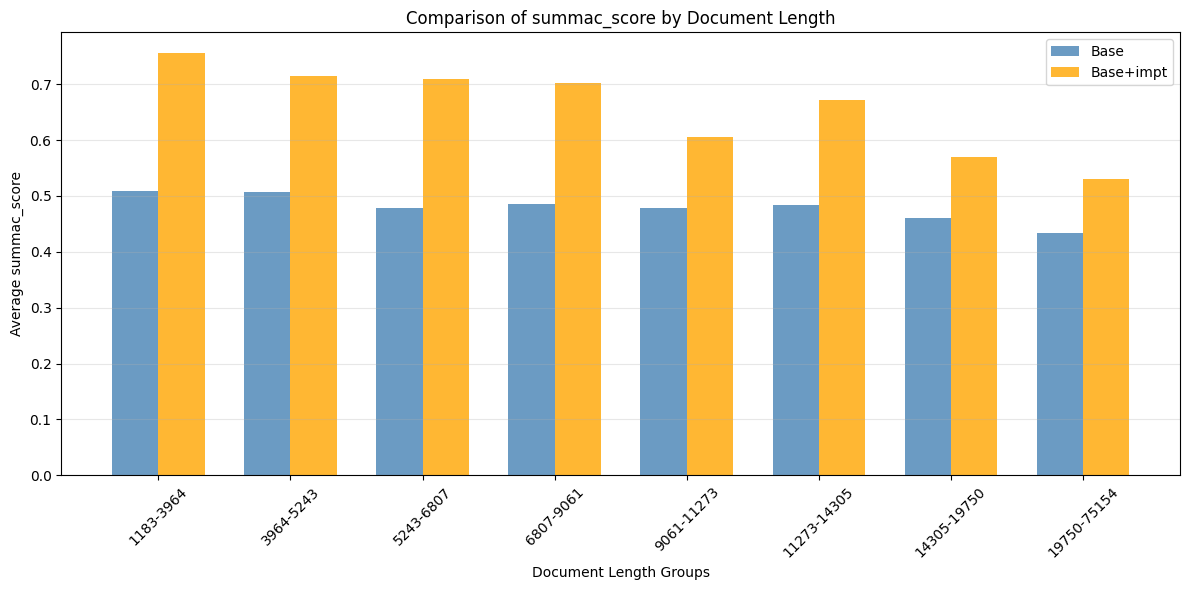

In [ ]:
# Summa-C against document length

plot_grouped_comparison(df1, df2, 'summac_score', 'Base', 'Base+impt')

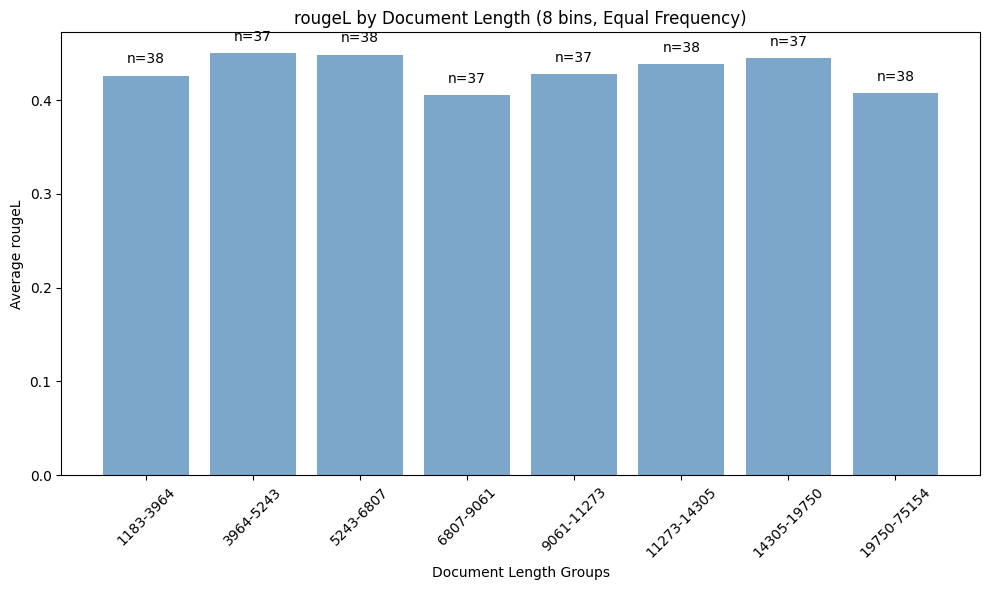

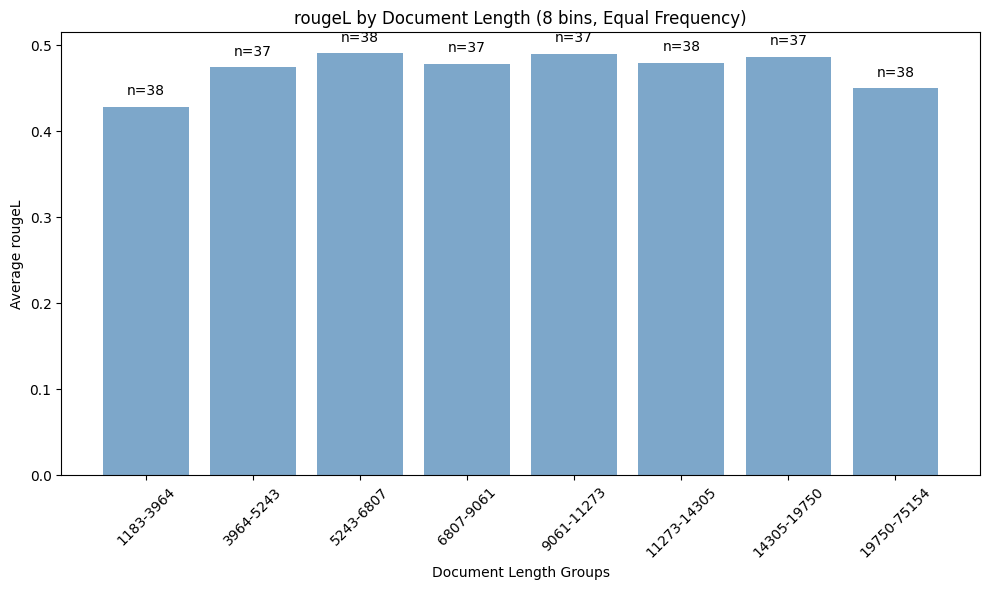

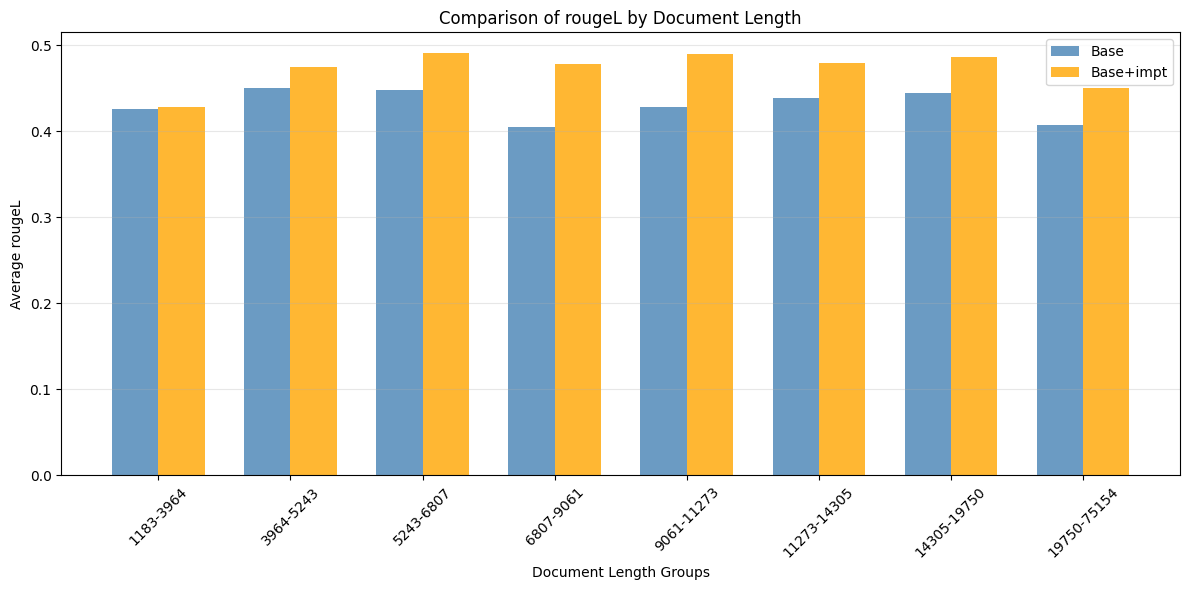

In [23]:
# Rouge-L against document length
data_path = "/mnt/ceph_rbd/project/context-faithful-llm/evaluate/logs/qwen3-8b_gov_report_validation_300_base/metrics_per_sample.json"
df1 = analyze_metric(data_path, 'rougeL', num_bins=8, method='quantile')

data_path = "/mnt/ceph_rbd/project/context-faithful-llm/evaluate/logs/qwen3-8b_gov_report_validation_300_attr-sent30_base+impt/metrics_per_sample.json"
df2 = analyze_metric(data_path, 'rougeL', num_bins=8, method='quantile')
plot_grouped_comparison(df1, df2, 'rougeL', 'Base', 'Base+impt')

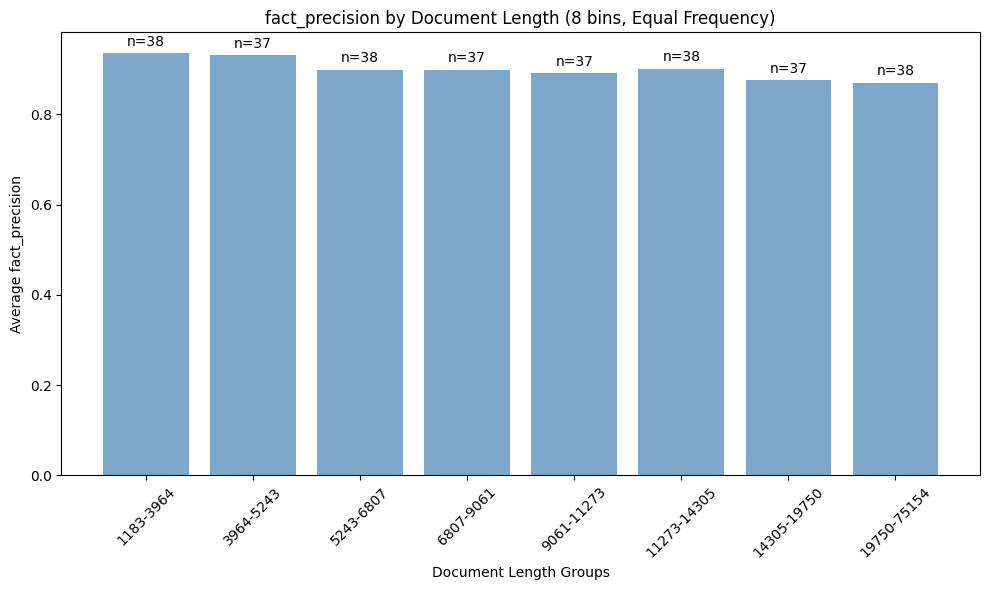

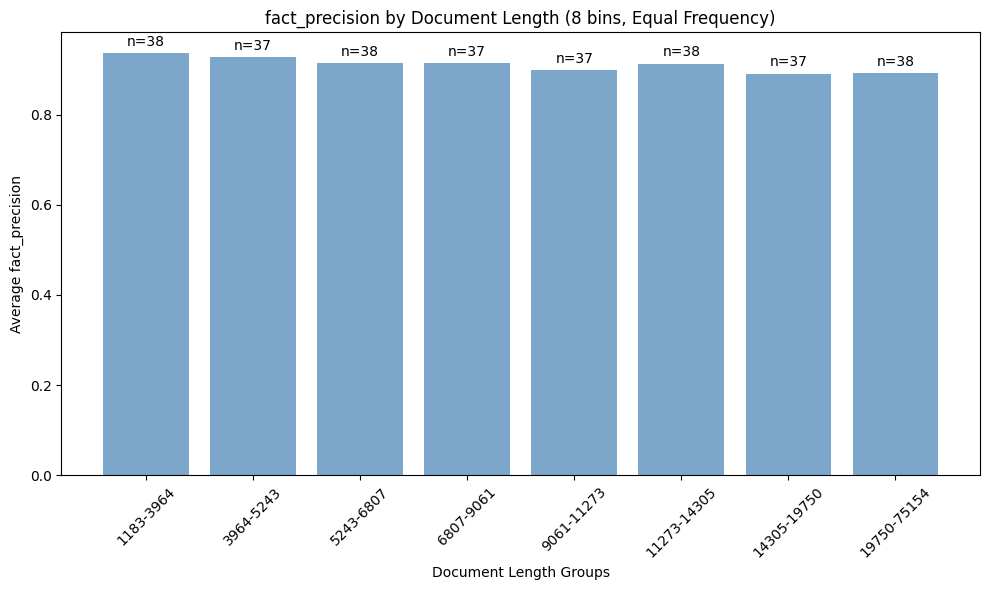

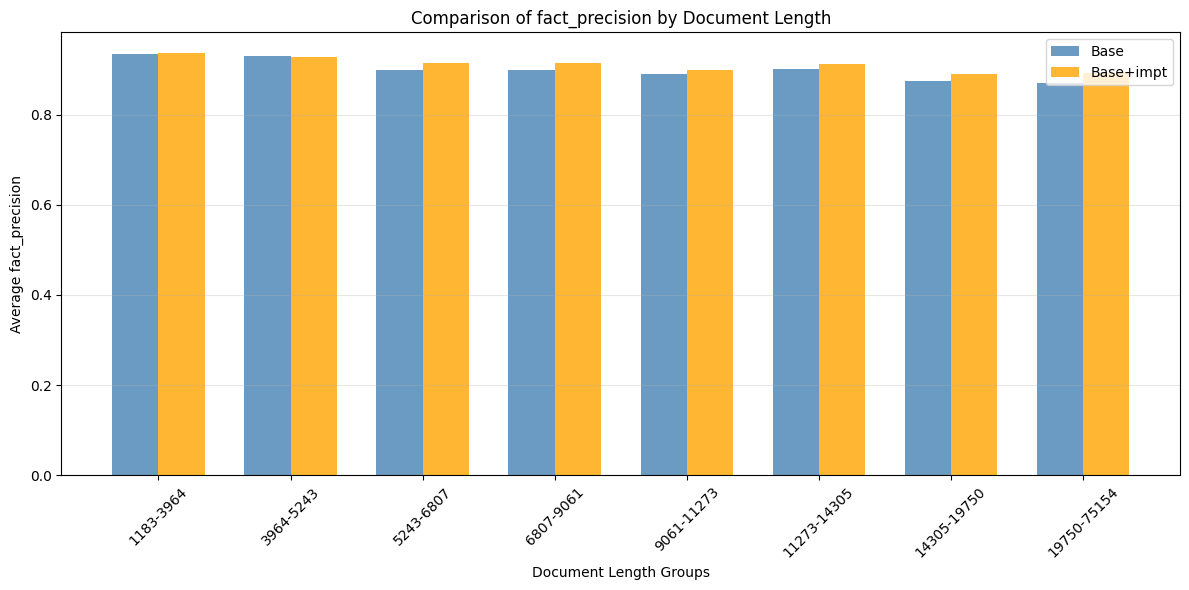

In [21]:
# FactScore against document length
data_path = "/mnt/ceph_rbd/project/context-faithful-llm/evaluate/exps/qwen3-8b_gov_report_validation_300_base_gpt-4o-mini/annotated_samples_factscore.json"
df1 = analyze_metric(data_path, 'fact_precision', num_bins=8, method='quantile')

data_path = "/mnt/ceph_rbd/project/context-faithful-llm/evaluate/exps/qwen3-8b_gov_report_validation_300_attr-sent30_base+impt_gpt-4o-mini/annotated_samples_factscore.json"
df2 = analyze_metric(data_path, 'fact_precision', num_bins=8, method='quantile')
plot_grouped_comparison(df1, df2, 'fact_precision', 'Base', 'Base+impt')